# IPL Data Visualization

Use Matplotlib and Seaborn to visualize the IPL pipeline stages from `main.ipynb`.

**Stages covered:**
- Data Ingestion
- Data Cleaning & Validation
- Data Transformation
- Core Analysis
- Derived Insights
- Reporting
- Data Export

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_theme(style="whitegrid")

# Load raw data for the pipeline stages
deliveries_df = pd.read_csv("../datasets/deliveries.csv")
matches_df = pd.read_csv("../datasets/matches.csv")

# Load exported analysis tables from main.ipynb
runs_per_match = pd.read_csv("../output/runs_per_match.csv", parse_dates=["date"])
top_batters = pd.read_csv("../output/top_batters.csv")
strike_rate = pd.read_csv("../output/strike_rate.csv")
economy = pd.read_csv("../output/economy.csv")
team_scores = pd.read_csv("../output/team_scores.csv")
death_overs = pd.read_csv("../output/death_overs.csv")

Stage 1 : Data Ingestion

C:\Users\stg3001\AppData\Local\Temp\ipykernel_14840\870877227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dataset_summary, x="dataset", y="rows", ax=axes[0], palette="Blues")
C:\Users\stg3001\AppData\Local\Temp\ipykernel_14840\870877227.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dataset_summary, x="dataset", y="columns", ax=axes[1], palette="Greens")


,dataset,rows,columns
0,deliveries,260920,17
1,matches,1095,20


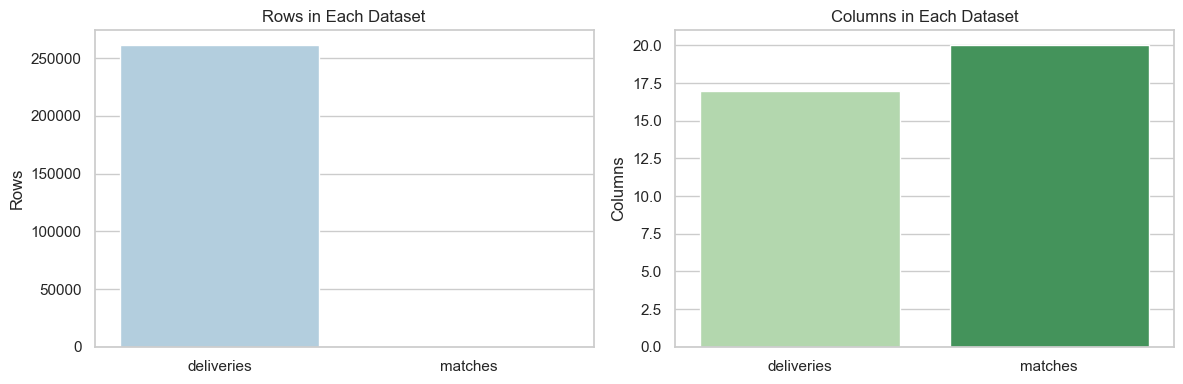

In [3]:
dataset_summary = pd.DataFrame({
    "dataset": ["deliveries", "matches"],
    "rows": [deliveries_df.shape[0], matches_df.shape[0]],
    "columns": [deliveries_df.shape[1], matches_df.shape[1]],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=dataset_summary, x="dataset", y="rows", ax=axes[0], palette="Blues")
axes[0].set_title("Rows in Each Dataset")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")

sns.barplot(data=dataset_summary, x="dataset", y="columns", ax=axes[1], palette="Greens")
axes[1].set_title("Columns in Each Dataset")
axes[1].set_xlabel("")
axes[1].set_ylabel("Columns")

plt.tight_layout()
display(dataset_summary)
plt.show()

Stage 2 : Data Cleaning & Validation

,deliveries_shape,matches_shape
0,"(260920, 17)","(1095, 20)"


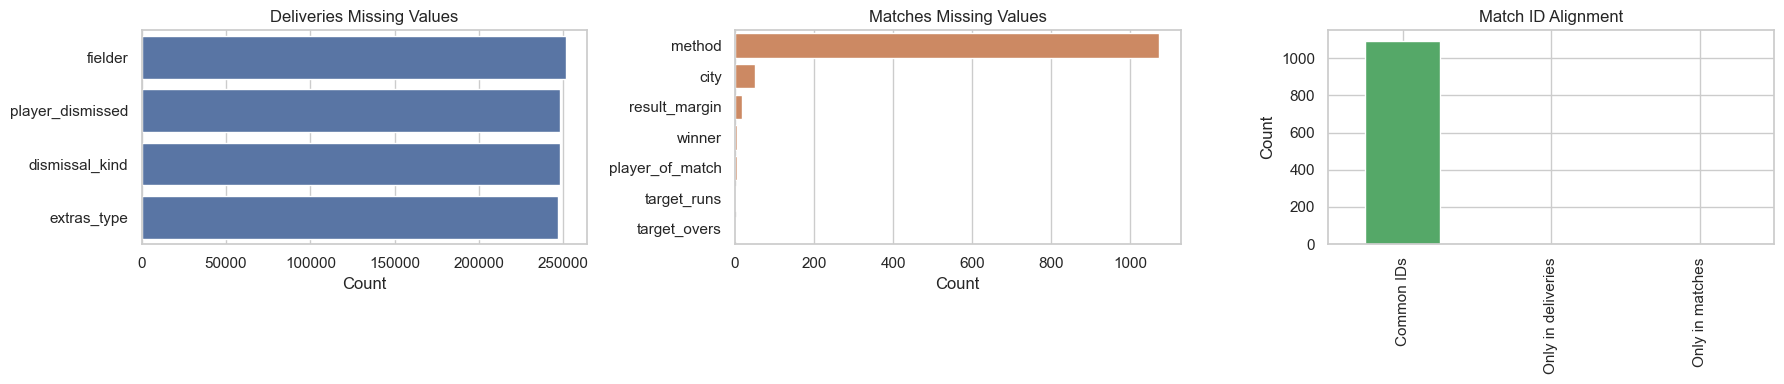

In [4]:
deliveries_clean = deliveries_df.copy()
matches_clean = matches_df.copy()

for col in deliveries_clean.select_dtypes(include=["object", "string"]).columns:
    deliveries_clean[col] = deliveries_clean[col].astype("string").str.strip()

for col in matches_clean.select_dtypes(include=["object", "string"]).columns:
    matches_clean[col] = matches_clean[col].astype("string").str.strip()

matches_clean["date"] = pd.to_datetime(matches_clean["date"], errors="coerce")

for col in ["match_id", "inning", "over", "ball", "batsman_runs", "extra_runs", "total_runs", "is_wicket"]:
    deliveries_clean[col] = pd.to_numeric(deliveries_clean[col], errors="coerce")

for col in ["id", "result_margin", "target_runs", "target_overs"]:
    matches_clean[col] = pd.to_numeric(matches_clean[col], errors="coerce")

missing_delivery = deliveries_df.isna().sum()[deliveries_df.isna().sum() > 0].sort_values(ascending=False)
missing_matches = matches_df.isna().sum()[matches_df.isna().sum() > 0].sort_values(ascending=False)

delivery_ids = set(deliveries_clean["match_id"].dropna().astype(int).unique())
match_ids = set(matches_clean["id"].dropna().astype(int).unique())
alignment = pd.Series({
    "Common IDs": len(delivery_ids & match_ids),
    "Only in deliveries": len(delivery_ids - match_ids),
    "Only in matches": len(match_ids - delivery_ids),
})

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

if missing_delivery.empty:
    axes[0].text(0.5, 0.5, "No missing values", ha="center", va="center")
else:
    sns.barplot(x=missing_delivery.values, y=missing_delivery.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Deliveries Missing Values")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

if missing_matches.empty:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center")
else:
    sns.barplot(x=missing_matches.values, y=missing_matches.index, ax=axes[1], color="#DD8452")
axes[1].set_title("Matches Missing Values")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

alignment.plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("Match ID Alignment")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")

plt.tight_layout()
display(pd.DataFrame({"deliveries_shape": [deliveries_clean.shape], "matches_shape": [matches_clean.shape]}))
plt.show()

Stage 3 : Data Transformation

C:\Users\stg3001\AppData\Local\Temp\ipykernel_14840\3963604178.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ipl_df, x="extras_type", order=extras_order, ax=axes[1], palette="Set2")


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,runs_per_ball
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,<NA>,Asad Rauf,RE Koertzen,1
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,<NA>,Asad Rauf,RE Koertzen,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,<NA>,Asad Rauf,RE Koertzen,1
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,<NA>,Asad Rauf,RE Koertzen,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,<NA>,Asad Rauf,RE Koertzen,0


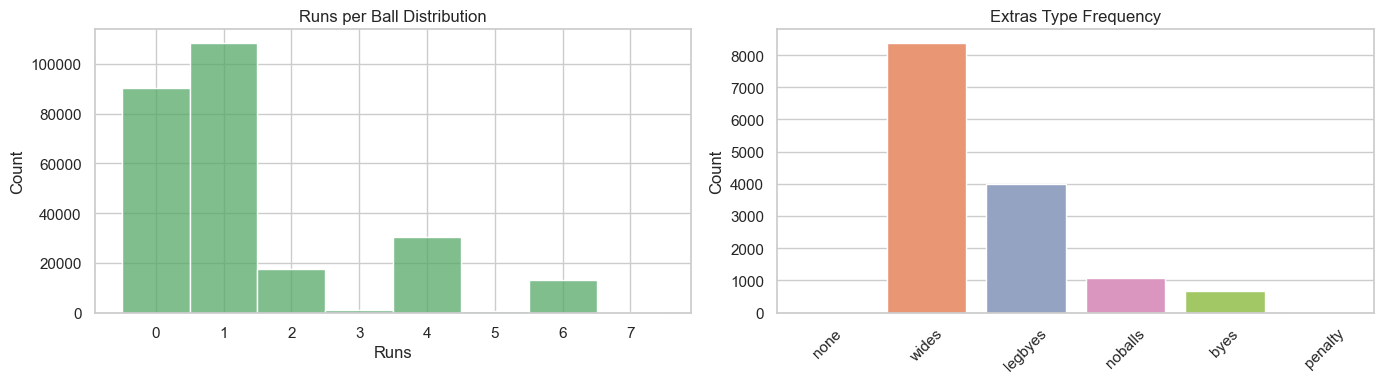

In [5]:
ipl_df = deliveries_clean.merge(matches_clean, left_on="match_id", right_on="id", how="inner")
ipl_df.columns = ipl_df.columns.str.strip().str.lower()
ipl_df["runs_per_ball"] = ipl_df["batsman_runs"] + ipl_df["extra_runs"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(ipl_df["runs_per_ball"], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5], discrete=True, ax=axes[0], color="#55A868")
axes[0].set_title("Runs per Ball Distribution")
axes[0].set_xlabel("Runs")
axes[0].set_ylabel("Count")

extras_order = ipl_df["extras_type"].fillna("none").value_counts().head(8).index
sns.countplot(data=ipl_df, x="extras_type", order=extras_order, ax=axes[1], palette="Set2")
axes[1].set_title("Extras Type Frequency")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

plt.tight_layout()
display(ipl_df.head())
plt.show()

Stage 4 : Core Analysis

KeyError: 'total_runs'

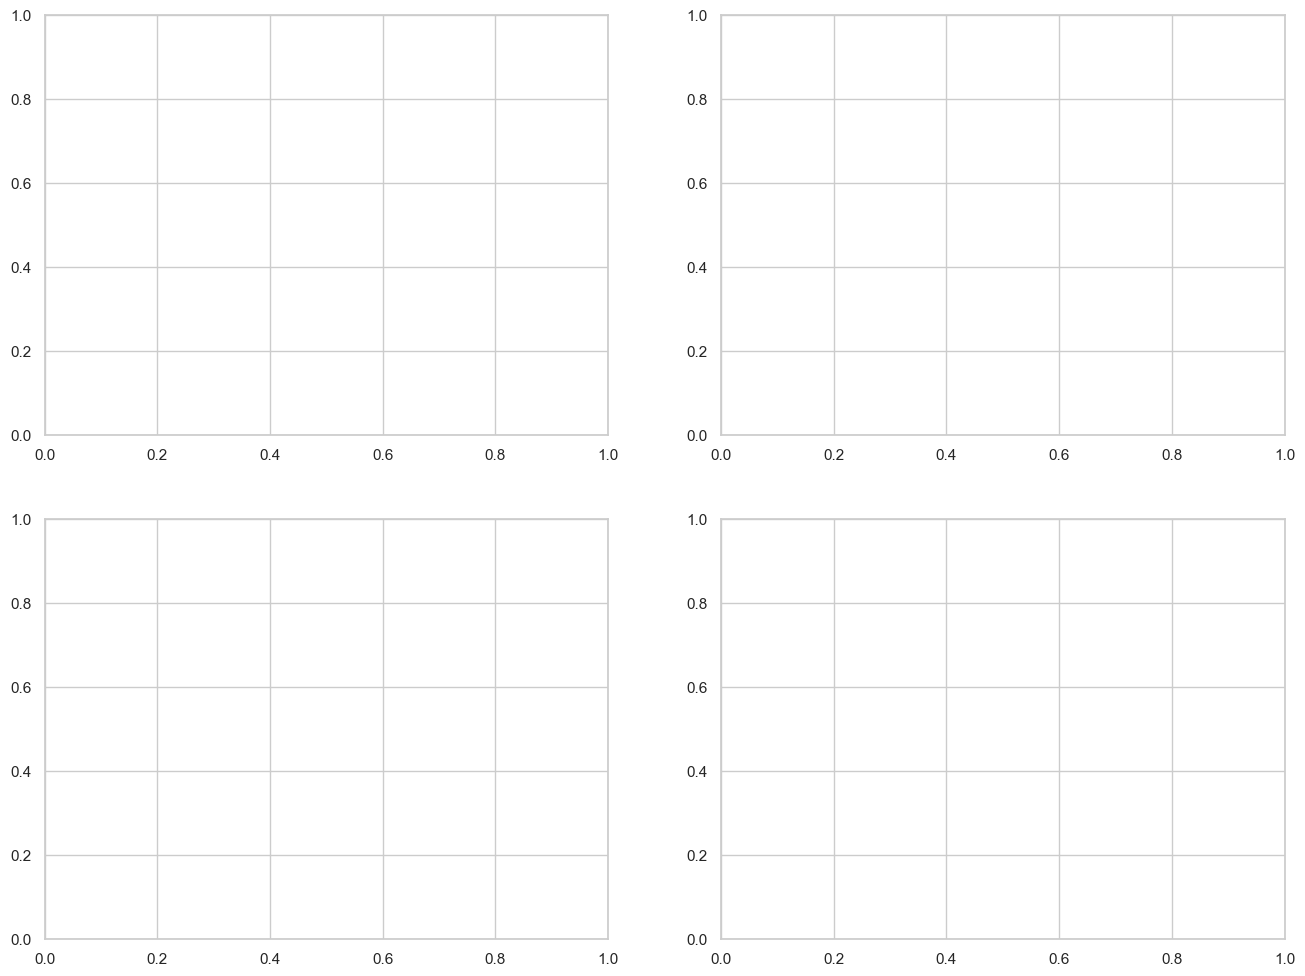

In [6]:
team_total_runs = team_scores.groupby("batting_team", as_index=False)["total_runs"].sum().sort_values("total_runs", ascending=False).head(10)
strike_top10 = strike_rate.sort_values("strike_rate", ascending=False).head(10)
economy_top10 = economy.sort_values("economy_rate", ascending=True).head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=top_batters.sort_values("total_runs", ascending=True), x="total_runs", y="batter", ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Top 10 Batters by Runs")
axes[0, 0].set_xlabel("Runs")
axes[0, 0].set_ylabel("")

sns.barplot(data=team_total_runs.sort_values("total_runs", ascending=True), x="total_runs", y="batting_team", ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Top 10 Teams by Total Runs")
axes[0, 1].set_xlabel("Runs")
axes[0, 1].set_ylabel("")

sns.barplot(data=strike_top10.sort_values("strike_rate", ascending=True), x="strike_rate", y="batter", ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Top 10 Batters by Strike Rate")
axes[1, 0].set_xlabel("Strike Rate")
axes[1, 0].set_ylabel("")

sns.barplot(data=economy_top10.sort_values("economy_rate", ascending=False), x="economy_rate", y="bowler", ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Top 10 Bowlers by Economy")
axes[1, 1].set_xlabel("Economy Rate")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

season_runs = runs_per_match.groupby("season", as_index=False)["runs_scored"].sum().sort_values("season")
death_team_runs = death_overs.groupby("batting_team", as_index=False)["runs_scored"].sum().sort_values("runs_scored", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.lineplot(data=season_runs, x="season", y="runs_scored", marker="o", ax=axes[0], color="#4C72B0")
axes[0].set_title("Season-wise Total Runs")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Runs")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=death_team_runs.sort_values("runs_scored", ascending=True), x="runs_scored", y="batting_team", ax=axes[1], color="#DD8452")
axes[1].set_title("Top 10 Teams in Death Overs")
axes[1].set_xlabel("Runs")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Stage 5 : Derived Insights

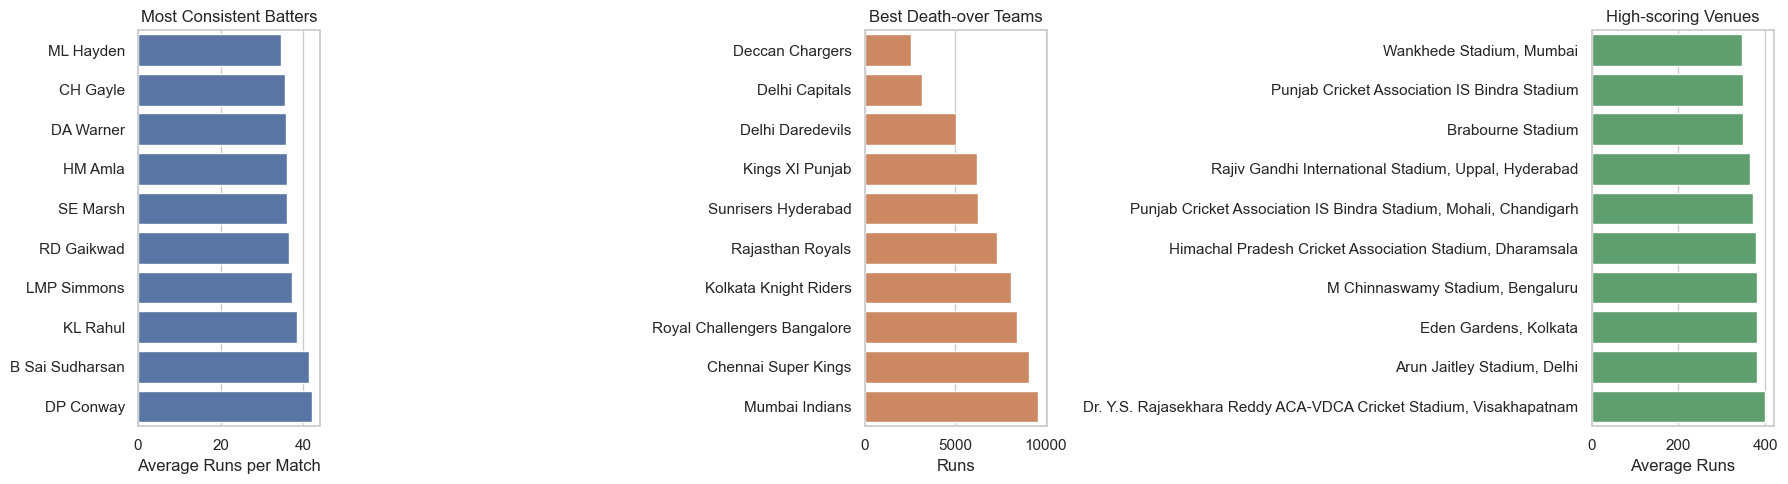

Most consistent batter: DP Conway
Best death-over team: Mumbai Indians
High-scoring venue: Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam


In [7]:
match_team_runs = ipl_df.groupby(["match_id", "batting_team"], as_index=False)["total_runs"].sum()
batter_match_runs = ipl_df.groupby(["batter", "match_id"], as_index=False)["batsman_runs"].sum()
consistent_batters = batter_match_runs.groupby("batter", as_index=False).agg(
    avg_runs_per_match=("batsman_runs", "mean"),
    matches_played=("match_id", "nunique")
)
consistent_batters = consistent_batters[consistent_batters["matches_played"] >= 10].sort_values("avg_runs_per_match", ascending=False).head(10)

match_runs = ipl_df.groupby("match_id", as_index=False)["total_runs"].sum().rename(columns={"total_runs": "match_runs"})
venue_summary = matches_clean.merge(match_runs, left_on="id", right_on="match_id", how="left").groupby("venue", as_index=False)["match_runs"].mean().rename(columns={"match_runs": "average_runs"}).sort_values("average_runs", ascending=False).head(10)

death_team_summary = death_overs.groupby("batting_team", as_index=False)["runs_scored"].sum().sort_values("runs_scored", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=consistent_batters.sort_values("avg_runs_per_match", ascending=True), x="avg_runs_per_match", y="batter", ax=axes[0], color="#4C72B0")
axes[0].set_title("Most Consistent Batters")
axes[0].set_xlabel("Average Runs per Match")
axes[0].set_ylabel("")

sns.barplot(data=death_team_summary.sort_values("runs_scored", ascending=True), x="runs_scored", y="batting_team", ax=axes[1], color="#DD8452")
axes[1].set_title("Best Death-over Teams")
axes[1].set_xlabel("Runs")
axes[1].set_ylabel("")

sns.barplot(data=venue_summary.sort_values("average_runs", ascending=True), x="average_runs", y="venue", ax=axes[2], color="#55A868")
axes[2].set_title("High-scoring Venues")
axes[2].set_xlabel("Average Runs")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

most_consistent_batter = consistent_batters.iloc[0]["batter"] if not consistent_batters.empty else "N/A"
best_death_team = death_team_summary.iloc[0]["batting_team"] if not death_team_summary.empty else "N/A"
high_scoring_venue = venue_summary.iloc[0]["venue"] if not venue_summary.empty else "N/A"

print("Most consistent batter:", most_consistent_batter)
print("Best death-over team:", best_death_team)
print("High-scoring venue:", high_scoring_venue)

Stage 6 : Reporting

C:\Users\stg3001\AppData\Local\Temp\ipykernel_14840\1340188464.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=report_summary, x="report", y="rows", palette="magma", ax=ax)


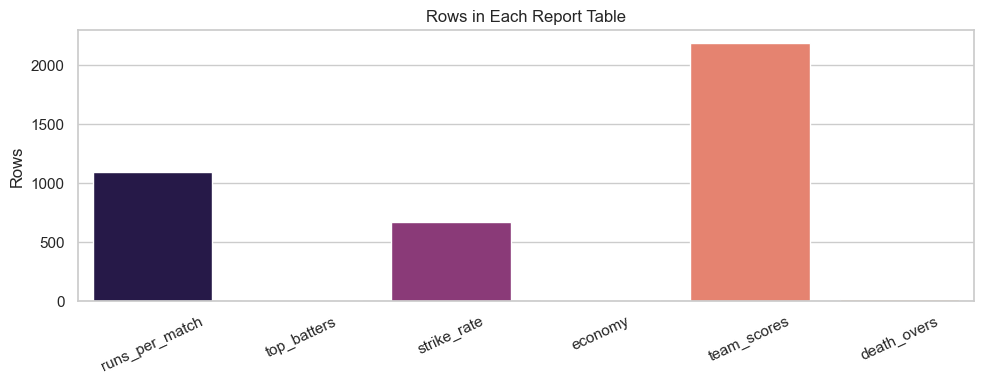

,report,rows
0,runs_per_match,1095
1,top_batters,10
2,strike_rate,673
3,economy,10
4,team_scores,2187
5,death_overs,19


,match_id,season,date,total_runs
0,1426268,2024,2024-04-15,549
1,1422126,2024,2024-03-27,523
2,1426280,2024,2024-04-26,523
3,1426281,2024,2024-04-27,504
4,419137,2009/10,2010-04-03,469


,batter,runs_scored
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536


In [10]:
reports = {
    "runs_per_match": runs_per_match.sort_values("total_runs", ascending=False),
    "top_batters": top_batters,
    "strike_rate": strike_rate.sort_values("strike_rate", ascending=False),
    "economy": economy.sort_values("economy_rate", ascending=True),
    "team_scores": team_scores,
    "death_overs": death_overs,
}

report_summary = pd.DataFrame({
    "report": list(reports.keys()),
    "rows": [frame.shape[0] for frame in reports.values()],
})

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=report_summary, x="report", y="rows", palette="magma", ax=ax)
ax.set_title("Rows in Each Report Table")
ax.set_xlabel("")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

display(report_summary)
display(reports["runs_per_match"].head())
display(reports["top_batters"].head())

Stage 7 : Data Export

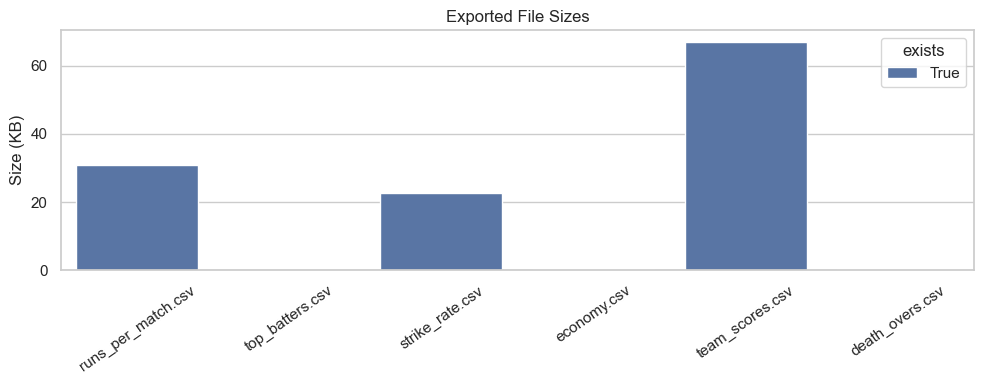

,file,exists,size_kb
0,runs_per_match.csv,True,31.00
1,top_batters.csv,True,0.18
2,strike_rate.csv,True,22.68
3,economy.csv,True,0.35
4,team_scores.csv,True,67.03
5,death_overs.csv,True,0.48


In [11]:
output_dir = "../output"
export_files = [
    "runs_per_match.csv",
    "top_batters.csv",
    "strike_rate.csv",
    "economy.csv",
    "team_scores.csv",
    "death_overs.csv",
]

export_summary = pd.DataFrame({
    "file": export_files,
    "exists": [os.path.exists(os.path.join(output_dir, name)) for name in export_files],
    "size_kb": [
        round(os.path.getsize(os.path.join(output_dir, name)) / 1024, 2)
        if os.path.exists(os.path.join(output_dir, name))
        else np.nan
        for name in export_files
    ],
})

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=export_summary, x="file", y="size_kb", hue="exists", dodge=False, ax=ax, palette={True: "#4C72B0", False: "#DD8452"})
ax.set_title("Exported File Sizes")
ax.set_xlabel("")
ax.set_ylabel("Size (KB)")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

display(export_summary)